 Copyright © Sorbonne University.

 This source code is licensed under the MIT license found in the
 LICENSE file in the root directory of this source tree.

# PLDAC - RL TABULAIRE


In this notebook, we will code a naive actor-critic algorithm in the tabular case using q-tables instead of the value function v.


## Install libraries

Installs the necessary Python and system libraries

In [1]:
try:
    from easypip import easyimport
except ModuleNotFoundError:
    from subprocess import run
    assert run(["pip", "install", "easypip"]).returncode == 0, "Could not install easypip"
    from easypip import easyimport

easyimport("swig")
easyimport("bbrl_utils").setup(maze_mdp=True)

import os
from pathlib import Path
from typing import List, Tuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bbrl_gymnasium.envs.maze_mdp import MazeMDPEnv
from bbrl_utils.notebook import tqdm
from mazemdp.mdp import Mdp
from mazemdp.toolbox import egreedy, egreedy_loc, sample_categorical, softmax
from mazemdp import random_policy
import bbrl_gymnasium  # noqa: F401

[easypip] Installing swig
[easypip] Installing bbrl_utils


Matplotlib backend: module://matplotlib_inline.backend_inline


/usr/local/lib/python3.11/dist-packages/bbrl_utils/notebook.py:46: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm  # noqa: F401
  if event.key is 'enter':



In [2]:
# matplotlib.use("TkAgg")

from functools import partial
!pip install optuna
import optuna
import yaml
import hydra
from omegaconf import OmegaConf, DictConfig

import seaborn as sns
sns.set_theme()
import logging
optuna.logging.set_verbosity(optuna.logging.WARNING)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 10.4 MB/s eta 0:00:00


# Step 1: Updating the naive Actor-critic algorithm with Q-values

We consider the naive actor-critic algorithm with a categorical policy.  
The algorithm learns a critic with the standard temporal difference mechanism  
using a learning rate \(\alpha_{critic}\).

We consider a **Q-value-based critic** \(Q(s, a)\) instead of a value-based critic \(V(s)\), which allows the algorithm to estimate the value of taking action \(a\) from state \(s\).  


---

## Critic Update Rules

We implement four different update rules for the Q-values:

1. **SARSA Update Rule**  
   $Q(s_t, a_t) ← Q(s_t, a_t) + alpha-critic [r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t)]$

   This rule follows the **on-policy** approach, where the next action is drawn according to the policy.  

2. **Q-learning Update Rule**  
   $Q(s_t, a_t) ← Q(s_t, a_t) + alpha-critic [r_{t+1} + \gamma max_a Q(s_{t+1}, a) - max_a Q(s_t, a)]$
   
   This rule follows the **off-policy** approach, where the best possible action is chosen greedily.  

3. **"Mean" SARSA Update Rule**  
   $Q(s_t, a_t) ← Q(s_t, a_t) + alpha-critic [r_{t+1} + \gamma max_a Q(s_{t+1}, a) - \Sigma_a \pi(a|s_t)  Q(s_t, a)]$
   
   This rule leverages the **expected value** of the Q-function over all actions, weighted by the current policy.  

4. **Fourth Update Rule**  
   $Q(s_t, a_t) ← Q(s_t, a_t) + alpha-critic [r_{t+1} + \gamma max_a Q(s_{t+1}, a) - Q(s_t, a_t)]$  
   This rule uses a one-step update towards the maximum Q-value of the next state.  
   
   

---

## Actor Update

To update the actor, the general idea is the same, using the temporal difference error with another learning rate $\alpha_{actor}$.

However, naively applying the same learning rule would not ensure that the probabilities of all actions in a state sum to 1.
Besides, when the temporal difference error $\delta_t$ is negative, it may happen that the probability of an action gets negative or null, which raises an issue when applying renormalization.

So, instead of applying the naive rule, we apply the following one:
$$
\pi_{temp}(a_t|s_t) =  \begin{cases}
\pi^{(i)}(a_t|s_t) + \alpha_{actor} \delta_t & \mathrm{if } \pi^{(i)}(a_t|s_t) + \alpha_{actor} \delta_t > 10^{-8}\\
10^{-8} & \mathrm{otherwise.} \\
\end{cases}
$$

Then we can apply renormalization so that the probabilities of actions still sum to 1, with
$$
\forall a, \pi^{(i+1)}(a|s_t) = \frac{\pi_{temp}^{(i+1)}(a|s_t)} {\sum_{a'} \pi_{temp}^{(i+1)}(a'|s_t)}
$$ with
$$
\pi_{temp}^{(i+1)}(a|s_t) =  \begin{cases}
\pi_{temp}(a|s_t) & \mathrm{if } a = a_t\\
\pi^{(i)}(a|s_t) & \mathrm{otherwise.} \\
\end{cases}
$$

---

## Implementation:

We provide a Python implementation of the naive actor-critic algorithm with Q-values using the four update rules.  


---


In [3]:
def renormalize(
    mdp: MazeMDPEnv,
    policy: np.array,
    state: np.array,
) -> None:
    """
    Renormalize the probability of actions so that the sum of probabilities over actions is always 1.
    We made sure in the calling function that the probabilities of action never get negative when they are decreased.
    :param mdp: the mdp the agent is working in (to get the number of actions)
    :param policy: the current policy, before normalization
    :param state: the state where the actions need to be renormalized
    :return: nothing
    """

    policy[state] = policy[state] / np.sum(policy[state])


In [4]:
import numpy as np

def perform_episode(
    mdp: MazeMDPEnv,
    policy: np.array,
    q: np.array,
    alpha_critic: float,
    alpha_actor: float,
    update_type: int,
    render: bool = True,
    stagnation_threshold: float = 0.1,
    max_no_improve: int = 5
) -> int:
    """
    Perform an episode on the given mdp with the given policy using Q-values.
    :param update_type: int indicating the chosen update rule (1, 2, 3, 4).
    :return: the number of steps before it stops
    """
    state, _ = mdp.reset(uniform=True)  # reinit env, get initial state
    terminated = False
    truncated = False
    steps = 0
    episode_rewards = []
    last_avg_reward = None
    no_improvement_count = 0

    while not (terminated or truncated):
        if steps % 10000 == 0:
            print(f"Step: {steps}, State: {state}, Terminated: {terminated}, Truncated: {truncated}")

        action = sample_categorical(policy[state])  # draw action from the policy
        next_state, reward, terminated, truncated, _ = mdp.step(action)

        # max Q-value for the next state
        max_q_next = np.max(q[next_state])

        # next action according to the current policy (for SARSA)
        next_action = sample_categorical(policy[next_state])

        # TD error (delta) based on the selected update type
        if update_type == 1:
            # 1: SARSA update rule
            delta = reward + mdp.gamma * q[next_state, next_action] * (1 - terminated) - q[state, action]
            print(f"delta ({update_type}) - State: {state}, Action: {action}, Delta: {delta}")

        elif update_type == 2:
            # 2: Q-learning update rule
            delta = reward + mdp.gamma * max_q_next * (1 - terminated) - np.max(q[state])
            print(f"delta ({update_type}) - State: {state}, Action: {action}, Delta: {delta}")

        elif update_type == 3:
            # 3: MEAN SARSA update rule
            sum = np.sum(policy[state] * q[state])
            delta = reward + mdp.gamma * max_q_next * (1 - terminated) - sum
            print(f"delta ({update_type}) - State: {state}, Action: {action}, Delta: {delta}")
            print(f"Perform Episode - Update Type 3 - State: {state}, Sum Q: {sum}, Delta: {delta}")

        elif update_type == 4:
            # 4: Fourth update rule
            delta = reward + mdp.gamma * max_q_next * (1 - terminated) - q[state, action]
            print(f"delta ({update_type}) - State: {state}, Action: {action}, Delta: {delta}")

        else:
            raise ValueError("Invalid update type")

        # Update the Q-value with the delta
        q[state, action] += alpha_critic * delta

        # Update the policy with the new Q-values using the softmax function
        policy_temp = policy[state, action] + alpha_actor * delta
        policy[state, action] = max(policy_temp, 1e-8)

        renormalize(mdp, policy, state)
        print(f"Policy sum for state {state}: {np.sum(policy[state])}")
        assert np.isclose(np.sum(policy[state]), 1.0), "Policy is not properly normalized!"

        # Move to the next state
        state = next_state
        steps += 1

        # Track the reward for averaging
        episode_rewards.append(reward)

        # Calculate the average reward over the last N steps
        avg_reward = np.mean(episode_rewards[-1000:])

        # Detect stagnation based on the reward change
        if last_avg_reward is not None and abs(avg_reward - last_avg_reward) < stagnation_threshold:
            no_improvement_count += 1
        else:
            no_improvement_count = 0

        last_avg_reward = avg_reward

        # Stop if stagnation persists for a number of episodes
        if no_improvement_count >= max_no_improve:
            print(f"Stagnation detected after {steps} steps. Avg reward: {avg_reward}")
            return np.linalg.norm(q), steps

        value_norm = np.linalg.norm(q)
        print(f"Norm of Q-values: {value_norm}")

    return np.linalg.norm(q), steps


Here comes the main actor-critic function. It should take the shown parameters as input and output a list of value norms and a list of number of steps,
corresponding to the evolution of these quantities through learning

In [14]:
def actor_critic_q(
    mdp: MazeMDPEnv,
    nb_episodes: int,
    alpha_critic: float,
    alpha_actor: float,
    update_type: int,
    render: bool = True,
) -> np.array:
    """
    Perform actor-critic training over a number of episodes with Q-values.
    :param update_type: int indicating the chosen update rule (1, 2, 3, 4).
    :return: a list of norm of Q values and a list of number of steps of episodes
    """
    # Initialize Q-values to zero
    q = np.zeros((mdp.nb_states, mdp.action_space.n)) # MAIN CHANGES FROM PREVIOUSLY

    # Initialize uniform policy
    policy = np.ones((mdp.nb_states, mdp.action_space.n)) / mdp.action_space.n

    # Store the number of steps and norms
    nb_steps = []
    value_norms = []

    for ep in range(nb_episodes):
        print(f" Actor_critic_q function - looping Episode {ep + 1}/{nb_episodes}")
        value_norm, steps = perform_episode(mdp, policy, q, alpha_critic, alpha_actor, update_type, render)
        value_norms.append(value_norm)
        nb_steps.append(steps)

    return value_norms, nb_steps, policy, q

## Provide a plot function

Your plot function should show the evolution through time of number of steps the agent takes to find the reward in the maze.
If your algorithm works, this number of steps should decrease through time.

Your plot function should also show a mean and a standard deviation (or some more advanced statistics) over a collection of learning runs.
Make sure that your figure complies with [The figure checklist](https://master-dac.isir.upmc.fr/The_figure_checklist.pdf).

In [6]:
def plot_steps(
    nb_runs: int = 5,
    nb_episodes: int = 20,
    alpha_critic: float = 0.01,
    alpha_actor: float = 0.01,
    render: bool = True
) -> None:
    """
    Plot the performance of the Actor-Critic algorithm over multiple runs with different update rules.
    Shows the mean and standard deviation of the number of steps per episode for each update rule.
    Also provides a summary table with mean and standard deviation values.
    :param nb_episodes: the number of episodes
    :param alpha_critic: the learning rate of the critic
    :param alpha_actor: the learning rate of the actor
    :param render: whether training should be rendered
    :param nb_runs: number of runs to perform
    :return: nothing
    """
    update_names = ["SARSA", "Q-learning", "Mean SARSA", "Fourth Rule"]
    all_results = []
    summary = []

    print("\nEntered plot_steps funtion\n")
    for update_type in range(1, 5):
        print(f"\nPlot_steps funtion - Update type {update_type}")
        all_steps = []
        all_vals = []

        for run in range(nb_runs):
            print(f"Plot_steps funtion - Run {run + 1} of {nb_runs}")
            vals, nb_steps = actor_critic_q(mdp, nb_episodes, alpha_critic, alpha_actor, update_type, render)
            all_steps.append(nb_steps)
            all_vals.append(vals)

        # Convert to numpy arrays
        all_steps = np.array(all_steps)
        mean_steps = np.mean(all_steps, axis=0)
        std_steps = np.std(all_steps, axis=0)
        all_results.append((update_names[update_type - 1], mean_steps, std_steps))
        summary.append([update_names[update_type - 1], np.mean(mean_steps), np.std(mean_steps)])

    # Create summary table
    summary_df = pd.DataFrame(summary, columns=["Update Rule", "Mean Steps", "Standard Deviation"])
    print("\nSummary Table:\n", summary_df)
    print("nb_episodes:", nb_episodes)

    # Plotting results
    plt.figure(figsize=(12, 8))
    plt.title("Actor-Critic Performance - Comparison of Update Rules")
    plt.xlabel("Episode")
    plt.ylabel("Number of Steps")
    plt.grid(True, linestyle="--", alpha=0.6)

    for name, mean_steps, std_steps in all_results:
        plt.plot(mean_steps, label=f"{name} - Mean Steps")
        plt.fill_between(range(nb_episodes), mean_steps - std_steps, mean_steps + std_steps, alpha=0.2)

    plt.legend(loc="upper right")
    plt.savefig("actor_critic_comparison.pdf")
    plt.show()


## Separating plot_steps into 2 functions

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
 Actor_critic_q function - looping Episode 38/100
Step: 0, State: 0, Terminated: False, Truncated: False
delta (4) - State: 0, Action: 1, Delta: 0.0
Policy sum for state 0: 1.0
Norm of Q-values: 1.2496399481450648
delta (4) - State: 1, Action: 3, Delta: 0.0
Policy sum for state 1: 1.0
Norm of Q-values: 1.2496399481450648
delta (4) - State: 1, Action: 3, Delta: 0.0
Policy sum for state 1: 1.0
Norm of Q-values: 1.2496399481450648
delta (4) - State: 1, Action: 3, Delta: 0.0
Policy sum for state 1: 1.0
Norm of Q-values: 1.2496399481450648
delta (4) - State: 1, Action: 3, Delta: 0.0
Policy sum for state 1: 1.0
Norm of Q-values: 1.2496399481450648
delta (4) - State: 1, Action: 0, Delta: 0.0
Policy sum for state 1: 1.0
Stagnation detected after 6 steps. Avg reward: 0.0
 Actor_critic_q function - looping Episode 39/100
Step: 0, State: 4, Terminated: False, Truncated: False
delta (4) - State: 4, Action: 0, Delta: 0.0


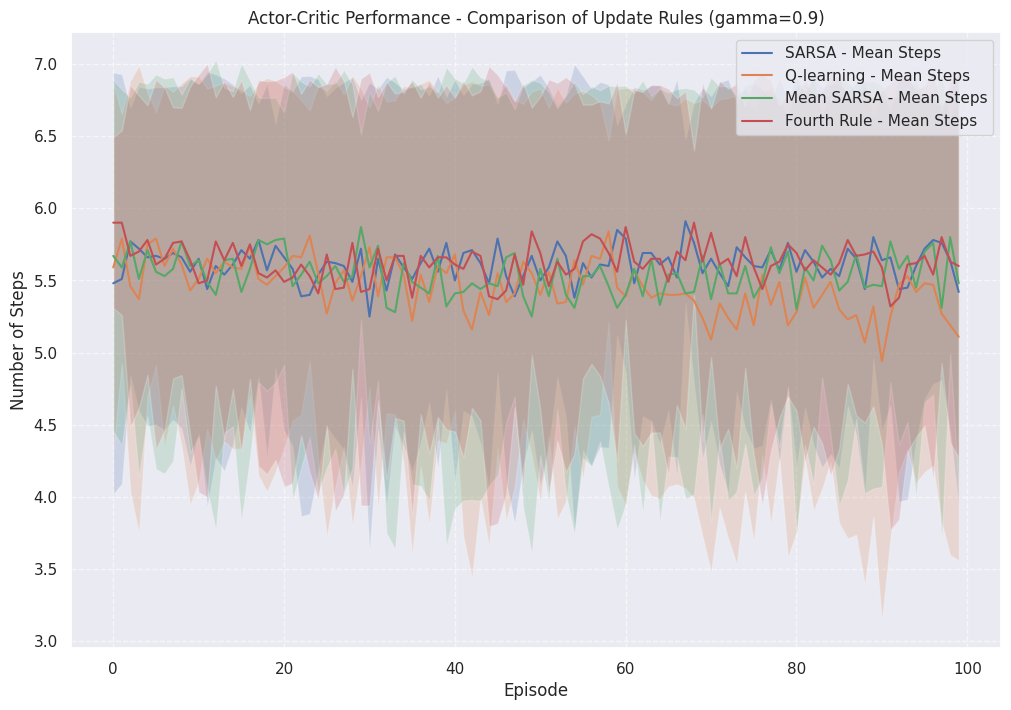

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
 Actor_critic_q function - looping Episode 29/100
Step: 0, State: 11, Terminated: False, Truncated: False
delta (4) - State: 11, Action: 3, Delta: 0.0
Policy sum for state 11: 1.0
Norm of Q-values: 2.1711606981051323
delta (4) - State: 7, Action: 1, Delta: 0.0
Policy sum for state 7: 1.0
Norm of Q-values: 2.1711606981051323
delta (4) - State: 7, Action: 2, Delta: 0.0
Policy sum for state 7: 1.0
Norm of Q-values: 2.1711606981051323
delta (4) - State: 11, Action: 2, Delta: 0.2321901158400001
Policy sum for state 11: 1.0000000000000002
Norm of Q-values: 2.1790921542992145
delta (4) - State: 15, Action: 3, Delta: 0.1671768834048001
Policy sum for state 15: 1.0
Norm of Q-values: 2.1831924806459817
delta (4) - State: 11, Action: 2, Delta: 0.046438023168
Policy sum for state 11: 1.0
Stagnation detected after 6 steps. Avg reward: 0.0
 Actor_critic_q function - looping Episode 30/100
Step: 0, State: 17, Terminated: Fa

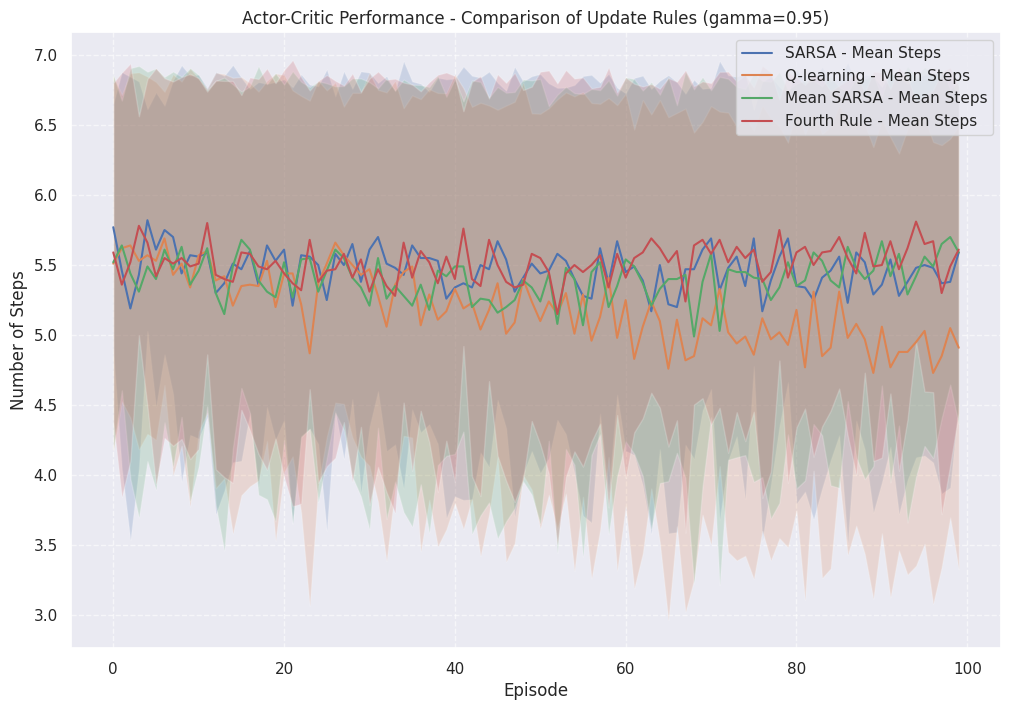

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Norm of Q-values: 3.083175051833042
delta (4) - State: 12, Action: 2, Delta: 0.029203210174463923
Policy sum for state 12: 1.0000000000000002
Norm of Q-values: 3.088549403472683
delta (4) - State: 15, Action: 3, Delta: 0.6494008738893006
Policy sum for state 15: 1.0000000000000002
Norm of Q-values: 3.131938564930146
delta (4) - State: 12, Action: 3, Delta: 0.527776677900583
Policy sum for state 12: 0.9999999999999999
Norm of Q-values: 3.160270563797916
delta (4) - State: 7, Action: 2, Delta: 0.06298234288865279
Policy sum for state 7: 1.0000000000000002
Norm of Q-values: 3.170006812852437
delta (4) - State: 12, Action: 3, Delta: 0.15090262245994662
Policy sum for state 12: 1.0000000000000002
Stagnation detected after 6 steps. Avg reward: 0.0
 Actor_critic_q function - looping Episode 34/100
Step: 0, State: 14, Terminated: False, Truncated: False
delta (4) - State: 14, Action: 1, Delta: 0.016238019870720044
Po

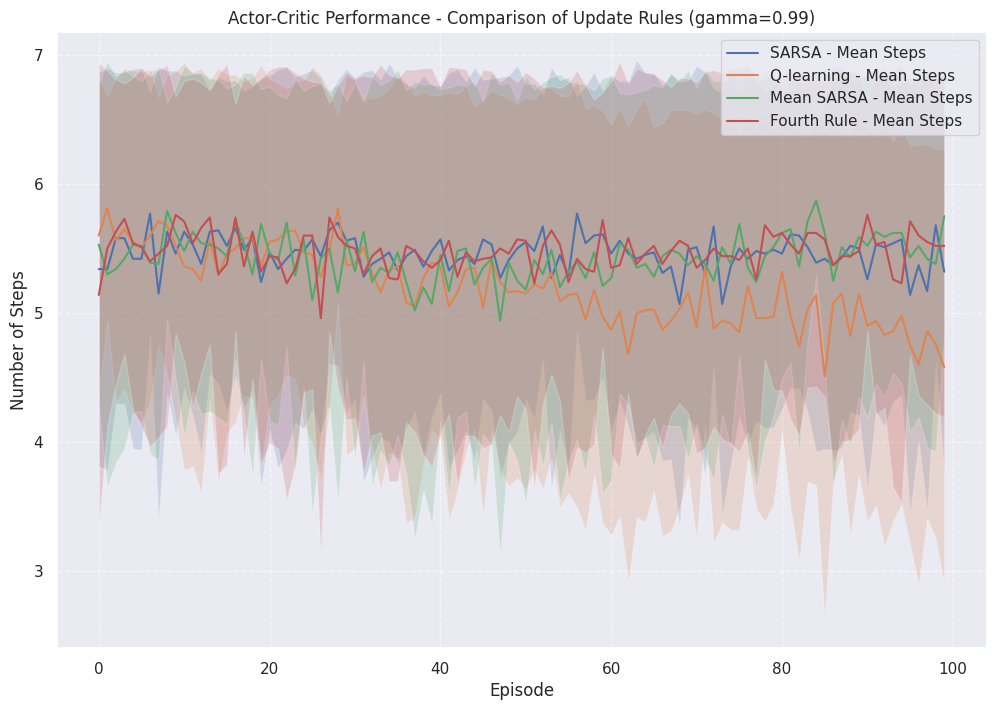

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Policy sum for state 10: 1.0
Stagnation detected after 6 steps. Avg reward: 0.0
 Actor_critic_q function - looping Episode 33/100
Step: 0, State: 18, Terminated: False, Truncated: False
delta (4) - State: 18, Action: 1, Delta: 0.45000000000000007
Policy sum for state 18: 1.0
Norm of Q-values: 1.0074720839804943
delta (4) - State: 19, Action: 3, Delta: 0.25
Policy sum for state 19: 1.0
Norm of Q-values: 1.1036870027322059
 Actor_critic_q function - looping Episode 34/100
Step: 0, State: 3, Terminated: False, Truncated: False
delta (4) - State: 3, Action: 0, Delta: 0.0
Policy sum for state 3: 1.0
Norm of Q-values: 1.1036870027322059
delta (4) - State: 2, Action: 0, Delta: 0.0
Policy sum for state 2: 1.0
Norm of Q-values: 1.1036870027322059
delta (4) - State: 1, Action: 3, Delta: 0.0
Policy sum for state 1: 1.0
Norm of Q-values: 1.1036870027322059
delta (4) - State: 1, Action: 0, Delta: 0.0
Policy sum for state 

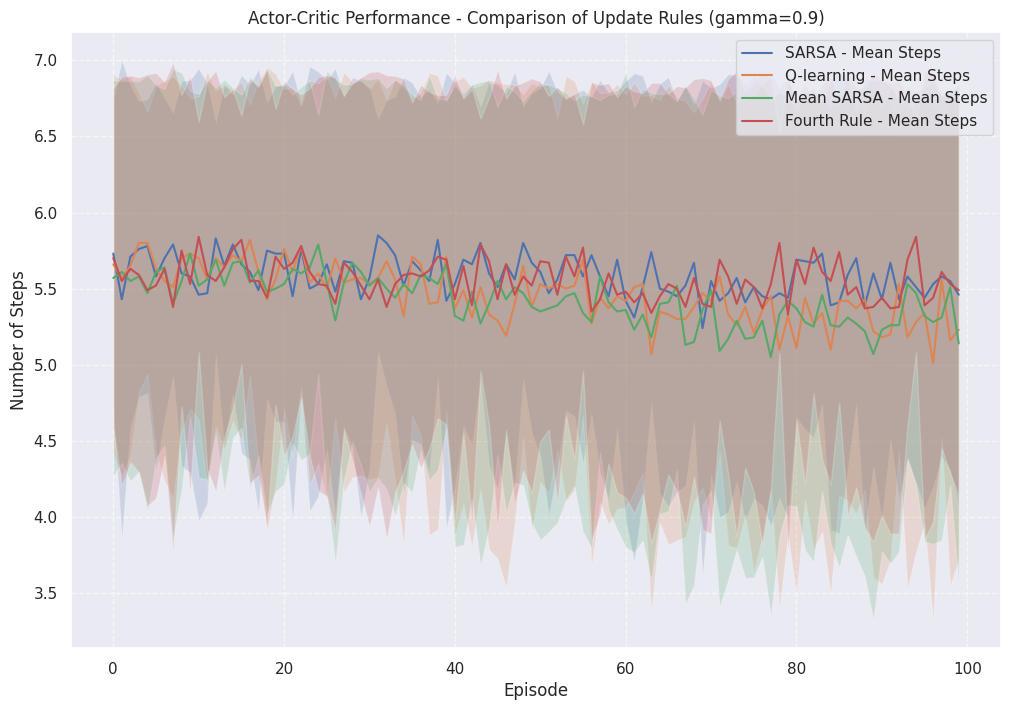

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
 Actor_critic_q function - looping Episode 23/100
Step: 0, State: 19, Terminated: False, Truncated: False
delta (4) - State: 19, Action: 0, Delta: 0.125
Policy sum for state 19: 1.0
Norm of Q-values: 1.6407870320701052
 Actor_critic_q function - looping Episode 24/100
Step: 0, State: 13, Terminated: False, Truncated: False
delta (4) - State: 13, Action: 2, Delta: 0.0
Policy sum for state 13: 1.0
Norm of Q-values: 1.6407870320701052
delta (4) - State: 17, Action: 3, Delta: 0.08201250000000002
Policy sum for state 17: 1.0
Norm of Q-values: 1.6412993624407726
delta (4) - State: 13, Action: 0, Delta: 0.0
Policy sum for state 13: 1.0
Norm of Q-values: 1.6412993624407726
delta (4) - State: 12, Action: 2, Delta: 0.0
Policy sum for state 12: 1.0
Norm of Q-values: 1.6412993624407726
delta (4) - State: 12, Action: 3, Delta: 0.008303765625000003
Policy sum for state 12: 0.9999999999999999
Norm of Q-values: 1.64130461379

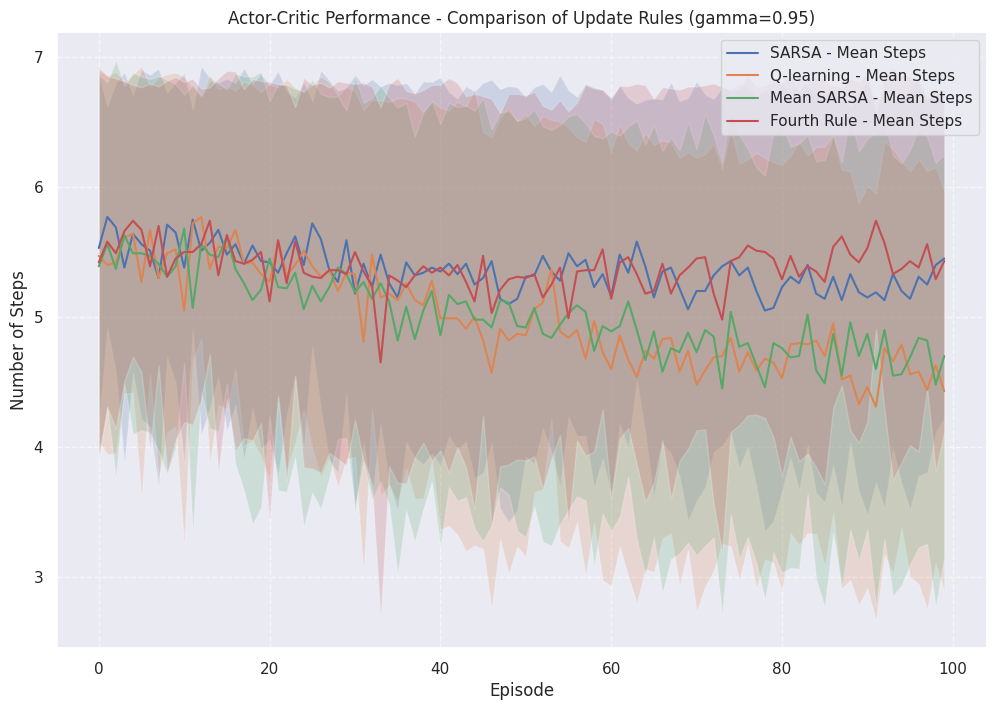

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Policy sum for state 13: 1.0
Norm of Q-values: 0.5
delta (4) - State: 9, Action: 3, Delta: 0.0
Policy sum for state 9: 1.0
Stagnation detected after 6 steps. Avg reward: 0.0
 Actor_critic_q function - looping Episode 33/100
Step: 0, State: 12, Terminated: False, Truncated: False
delta (4) - State: 12, Action: 3, Delta: 0.0
Policy sum for state 12: 1.0
Norm of Q-values: 0.5
delta (4) - State: 7, Action: 3, Delta: 0.0
Policy sum for state 7: 1.0
Norm of Q-values: 0.5
delta (4) - State: 4, Action: 2, Delta: 0.0
Policy sum for state 4: 1.0
Norm of Q-values: 0.5
delta (4) - State: 7, Action: 2, Delta: 0.0
Policy sum for state 7: 1.0
Norm of Q-values: 0.5
delta (4) - State: 12, Action: 0, Delta: 0.0
Policy sum for state 12: 1.0
Norm of Q-values: 0.5
delta (4) - State: 11, Action: 0, Delta: 0.0
Policy sum for state 11: 1.0
Stagnation detected after 6 steps. Avg reward: 0.0
 Actor_critic_q function - looping Episode 

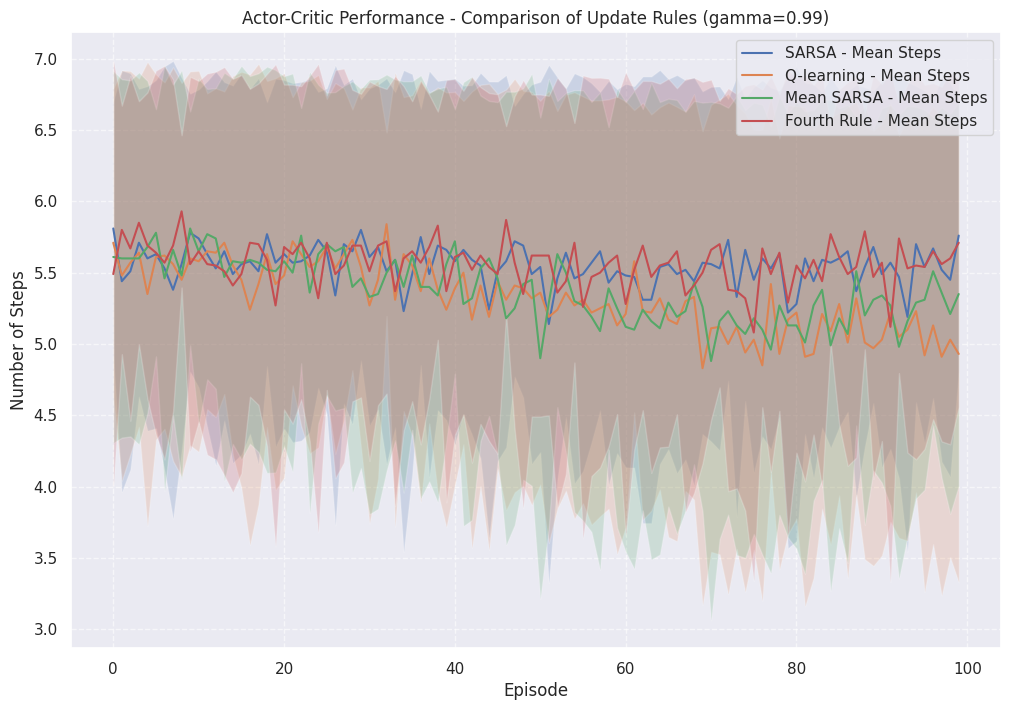

In [7]:
import time
from datetime import timedelta


def make_mdp(cfg):
    mdp = gym.make(cfg.mdp.name, kwargs={"width": cfg.mdp.width, "height": cfg.mdp.height, "ratio": cfg.mdp.ratio}, render_mode=cfg.mdp.render_mode)
    mdp = mdp.unwrapped
    return mdp

# ========== Fonctions Algorithmiques ==========
def run_experiment(cfg, nb_runs):
    """ Exécute l'algorithme Actor-Critic et retourne les résultats. """
    mdp = make_mdp(cfg)  # Créer un nouvel environnement avec les paramètres actuels
    update_names = ["SARSA", "Q-learning", "Mean SARSA", "Fourth Rule"]
    all_results = []
    summary = []

    for update_type in range(1, 5):
        all_steps = []

        for run in range(nb_runs):
            _, nb_steps = actor_critic_q(mdp, cfg.nb_episodes, cfg.alpha_critic, cfg.alpha_actor, update_type, cfg.render)
            all_steps.append(nb_steps)

        # Convertir en numpy arrays pour le calcul des statistiques
        all_steps = np.array(all_steps)
        mean_steps = np.mean(all_steps, axis=0)
        std_steps = np.std(all_steps, axis=0)

        all_results.append((update_names[update_type - 1], mean_steps, std_steps))
        summary.append([update_names[update_type - 1], np.mean(mean_steps), np.std(mean_steps)])

    return all_results, summary


# ========== Fonction pour le tracé des résultats ==========
def plot_results(all_results, cfg):
    """ Affiche les courbes de performance en fonction des mises à jour et enregistre les plots. """

    # Créer le dossier "plots" si nécessaire
    if not os.path.exists('plots'):
        os.makedirs('plots')

    # Création du plot
    plt.figure(figsize=(12, 8))
    plt.title(f"Actor-Critic Performance - Comparison of Update Rules (gamma={cfg.mdp.gamma})")
    plt.xlabel("Episode")
    plt.ylabel("Number of Steps")
    plt.grid(True, linestyle="--", alpha=0.6)

    for name, mean_steps, std_steps in all_results:
        plt.plot(mean_steps, label=f"{name} - Mean Steps")
        plt.fill_between(range(cfg.nb_episodes), mean_steps - std_steps, mean_steps + std_steps, alpha=0.2)

    plt.legend(loc="upper right")

    # Générer un nom de fichier basé sur les paramètres
    plot_filename = f"actor_critic_comparison_gamma_{cfg.mdp.gamma}_alpha_critic_{cfg.alpha_critic}_alpha_actor_{cfg.alpha_actor}.pdf"
    plot_filepath = os.path.join('plots', plot_filename)

    # Sauvegarder le plot dans le dossier "plots"
    plt.savefig(plot_filepath)
    print(f"Plot saved to {plot_filepath}")

    # Afficher le plot
    plt.show()


# ========== Exécution des tests sur plusieurs configurations ==========
# les taux d'apprentissages
hyperparameter_tests = [
    {"alpha_critic": 0.8, "alpha_actor": 0.5},  # Critic fort
    {"alpha_critic": 0.5, "alpha_actor": 0.8},  # Actor fort
]

gammas = [0.9, 0.95, 0.99]  # Test sur différentes valeurs de gamma

N = 100  # Nombre de runs

for params in hyperparameter_tests:
    for gamma in gammas:
        print(f"\n\nTest avec alpha_critic={params['alpha_critic']}, alpha_actor={params['alpha_actor']} et gamma={gamma}")

        ac_params = {
            "save_curves": False,
            "save_heatmap": True,
            "mdp": {
                "name": "MazeMDP-v0",
                "width": 5,
                "height": 5,
                "ratio": 0.2,
                "render_mode": "rgb_array",
                "gamma": gamma,
            },
            "log_dir": "./tmp",
            "video_dir": "./tmp/videos",
            "nb_episodes": 100,
            "render": False,
            "nb_repeats": 5,
            "alpha_critic": params["alpha_critic"],
            "alpha_actor": params["alpha_actor"],
        }

        cfg = OmegaConf.create(ac_params)

        # Lancer le test et mesurer le temps d'exécution
        start_time = time.time()
        all_results, summary = run_experiment(cfg, N)
        end_time = time.time()

        elapsed_time = timedelta(seconds=(end_time - start_time))
        print(f"Temps d'exécution pour {N} runs avec gamma = {gamma} : {elapsed_time}\n")

        # Affichage des résultats
        summary_df = pd.DataFrame(summary, columns=["Update Rule", "Mean Steps", "Standard Deviation"])
        print("\nRésumé des résultats :\n", summary_df)

        plot_results(all_results, cfg)  # Tracer les résultats


## Actor-critic hyper-parameters

To represent the hyper-parameters of the experiments performed in this notebook, we suggest using the dictionary below.
This dictionary can be read using omegaconf.
Using it is not mandatory.
You can also change the value of hyper-parameters or environment parameters at will.

## Test your code

The code for testing what you did so far is provided below.

In [8]:
# default given initially
ac_params = {
    "save_curves": False,
    "save_heatmap": True,
    "mdp": {
        "name": "MazeMDP-v0",
        "width": 5,
        "height": 5,
        "ratio": 0.0,
        "render_mode": "rgb_array",
        },

    "log_dir": "./tmp",
    "video_dir": "./tmp/videos",

    "nb_episodes": 30,
    "render": False, # True, #
    "nb_repeats": 5,

    "alpha_critic": 0.5,
    "alpha_actor": 0.5,
    }

def make_mdp(cfg):
    mdp = gym.make(cfg.mdp.name, kwargs={"width": cfg.mdp.width, "height": cfg.mdp.height, "ratio": cfg.mdp.ratio}, render_mode=cfg.mdp.render_mode)
    mdp = mdp.unwrapped
    return mdp

cfg=OmegaConf.create(ac_params)
mdp = make_mdp(cfg) # the mdp is made once and for all, this is an ugly global variable

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Norm of Q-values: 0.0
delta (3) - State: 6, Action: 2, Delta: 0.0
Perform Episode - Update Type 3 - State: 6, Sum Q: 0.0, Delta: 0.0
Policy sum for state 6: 1.0
Norm of Q-values: 0.0
delta (3) - State: 11, Action: 0, Delta: 0.0
Perform Episode - Update Type 3 - State: 11, Sum Q: 0.0, Delta: 0.0
Policy sum for state 11: 1.0
Stagnation detected after 6 steps. Avg reward: 0.0
 Actor_critic_q function - looping Episode 5/30
Step: 0, State: 4, Terminated: False, Truncated: False
delta (3) - State: 4, Action: 1, Delta: 0.0
Perform Episode - Update Type 3 - State: 4, Sum Q: 0.0, Delta: 0.0
Policy sum for state 4: 1.0
Norm of Q-values: 0.0
delta (3) - State: 4, Action: 1, Delta: 0.0
Perform Episode - Update Type 3 - State: 4, Sum Q: 0.0, Delta: 0.0
Policy sum for state 4: 1.0
Norm of Q-values: 0.0
delta (3) - State: 4, Action: 3, Delta: 0.0
Perform Episode - Update Type 3 - State: 4, Sum Q: 0.0, Delta: 0.0
Policy sum

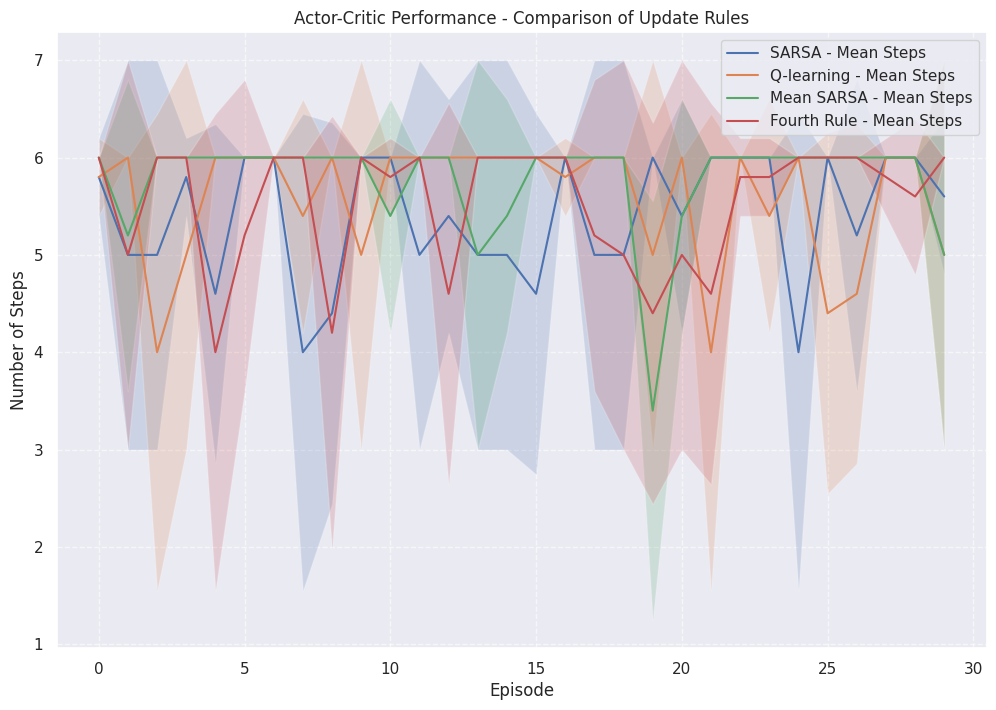

In [9]:
plot_steps(nb_runs=cfg.nb_repeats, nb_episodes=cfg.nb_episodes, alpha_actor=cfg.alpha_actor, alpha_critic=cfg.alpha_critic)

# print("average v value:", v_vals.mean())

### More tests...

Streaming output truncated to the last 5000 lines.
Policy sum for state 3: 1.0
Norm of Q-values: 0.01
delta (4) - State: 3, Action: 1, Delta: 0.0
Policy sum for state 3: 1.0
Norm of Q-values: 0.01
delta (4) - State: 3, Action: 3, Delta: 0.0
Policy sum for state 3: 1.0
Norm of Q-values: 0.01
delta (4) - State: 3, Action: 3, Delta: 0.0
Policy sum for state 3: 1.0
Norm of Q-values: 0.01
delta (4) - State: 3, Action: 0, Delta: 0.0
Policy sum for state 3: 1.0
Norm of Q-values: 0.01
delta (4) - State: 3, Action: 1, Delta: 0.0
Policy sum for state 3: 1.0
Stagnation detected after 6 steps. Avg reward: 0.0
 Actor_critic_q function - looping Episode 17/20
Step: 0, State: 16, Terminated: False, Truncated: False
delta (4) - State: 16, Action: 0, Delta: 0.0
Policy sum for state 16: 1.0
Norm of Q-values: 0.01
delta (4) - State: 16, Action: 3, Delta: 0.0
Policy sum for state 16: 1.0
Norm of Q-values: 0.01
delta (4) - State: 12, Action: 0, Delta: 0.0
Policy sum for state 12: 1.0
Norm of Q-values: 0.01

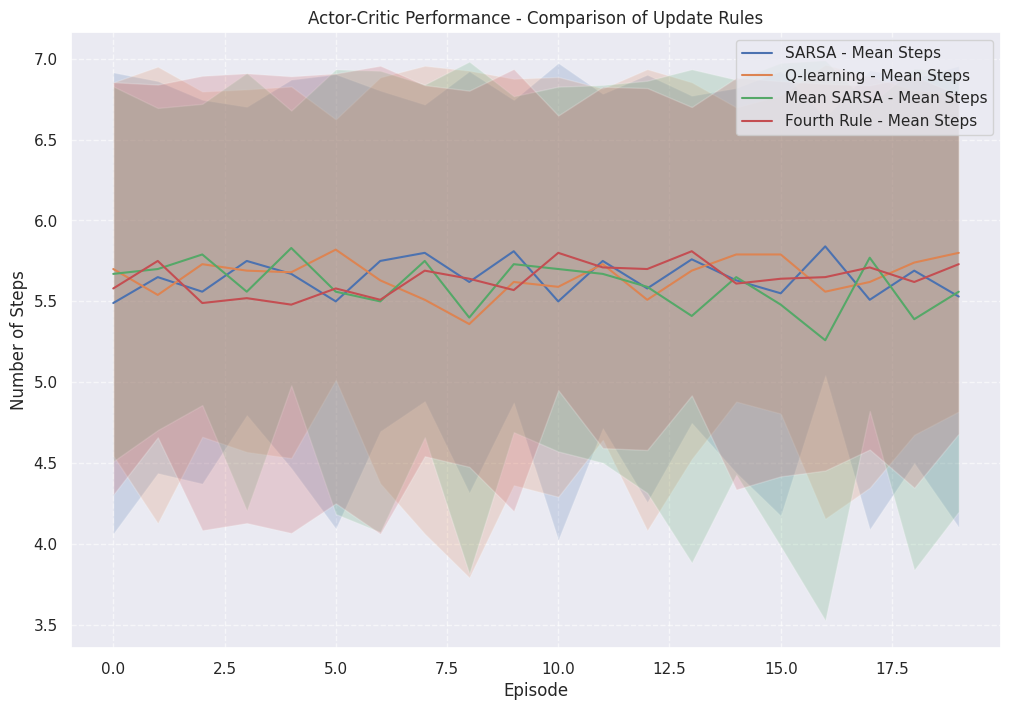

Temps d'exécution pour 100 runs : 0:00:06.806045


In [ ]:
ac_params = {
    "save_curves": False,
    "save_heatmap": True,
    "mdp": {
        "name": "MazeMDP-v0",
        "width": 5,
        "height": 5,
        "ratio": 0.2,
        "render_mode": "rgb_array",
        },

    "log_dir": "./tmp",
    "video_dir": "./tmp/videos",

    "nb_episodes": 100,
    "render": False, # True, #
    "nb_repeats": 5,

    "alpha_critic": 0.8, # ICI ON AUGMENTE LEARNING RATE DU CRITIC (because drives actor's LR)
    "alpha_actor": 0.5,
    }

cfg=OmegaConf.create(ac_params)
mdp = make_mdp(cfg) # the mdp is made once and for all, this is an ugly global variable

import time
from datetime import timedelta
N = 100

start_time = time.time()  # mesurer temps
plot_steps(nb_runs=N)
end_time = time.time()

elapsed_time = timedelta(seconds=(end_time - start_time))
print(f"Temps d'exécution pour {N} runs : {elapsed_time}")

# print("average v value:", v_vals.mean())

Streaming output truncated to the last 5000 lines.
Stagnation detected after 6 steps. Avg reward: 0.0
 Actor_critic_q function - looping Episode 18/20
Step: 0, State: 3, Terminated: False, Truncated: False
delta (4) - State: 3, Action: 3, Delta: 0.0
Policy sum for state 3: 1.0
Norm of Q-values: 0.014142422068677513
delta (4) - State: 3, Action: 1, Delta: 0.0
Policy sum for state 3: 1.0
Norm of Q-values: 0.014142422068677513
delta (4) - State: 3, Action: 2, Delta: 0.0
Policy sum for state 3: 1.0
Norm of Q-values: 0.014142422068677513
delta (4) - State: 8, Action: 2, Delta: 0.0
Policy sum for state 8: 1.0
Norm of Q-values: 0.014142422068677513
delta (4) - State: 8, Action: 0, Delta: 0.0
Policy sum for state 8: 1.0
Norm of Q-values: 0.014142422068677513
delta (4) - State: 7, Action: 2, Delta: 6.561000000000002e-09
Policy sum for state 7: 1.0
Stagnation detected after 6 steps. Avg reward: 0.0
 Actor_critic_q function - looping Episode 19/20
Step: 0, State: 10, Terminated: False, Truncated:

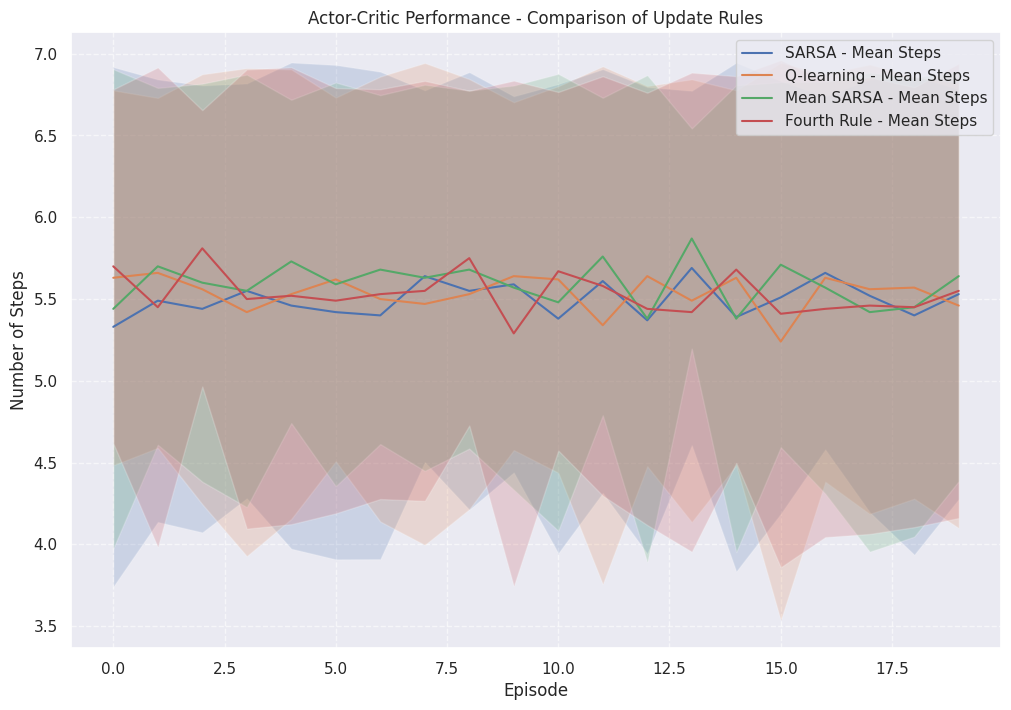

Temps d'exécution pour 100 runs : 0:00:06.258326


In [ ]:
ac_params = {
    "save_curves": False,
    "save_heatmap": True,
    "mdp": {
        "name": "MazeMDP-v0",
        "width": 5,
        "height": 5,
        "ratio": 0.2,
        "render_mode": "rgb_array",
        },

    "log_dir": "./tmp",
    "video_dir": "./tmp/videos",

    "nb_episodes": 100,
    "render": False, # True, #
    "nb_repeats": 5,

    "alpha_critic": 0.5, # CAS inverse du précédent (à titre d'observation)
    "alpha_actor": 0.8,
    }

cfg=OmegaConf.create(ac_params)
mdp = make_mdp(cfg) # the mdp is made once and for all, this is an ugly global variable

import time
from datetime import timedelta
N = 100

start_time = time.time()  # mesurer temps
plot_steps(nb_runs=N)
end_time = time.time()

elapsed_time = timedelta(seconds=(end_time - start_time))
print(f"Temps d'exécution pour {N} runs : {elapsed_time}")

# print("average v value:", v_vals.mean())

Streaming output truncated to the last 5000 lines.
Policy sum for state 10: 1.0
Norm of Q-values: 0.01414213562373095
delta (4) - State: 9, Action: 1, Delta: 0.0
Policy sum for state 9: 1.0
Stagnation detected after 6 steps. Avg reward: 0.0
 Actor_critic_q function - looping Episode 17/20
Step: 0, State: 1, Terminated: False, Truncated: False
delta (4) - State: 1, Action: 3, Delta: 0.0
Policy sum for state 1: 1.0
Norm of Q-values: 0.01414213562373095
delta (4) - State: 1, Action: 3, Delta: 0.0
Policy sum for state 1: 1.0
Norm of Q-values: 0.01414213562373095
delta (4) - State: 1, Action: 0, Delta: 0.0
Policy sum for state 1: 1.0
Norm of Q-values: 0.01414213562373095
delta (4) - State: 1, Action: 1, Delta: 0.0
Policy sum for state 1: 1.0
Norm of Q-values: 0.01414213562373095
delta (4) - State: 1, Action: 2, Delta: 0.0
Policy sum for state 1: 1.0
Norm of Q-values: 0.01414213562373095
delta (4) - State: 5, Action: 0, Delta: 0.0
Policy sum for state 5: 1.0
Stagnation detected after 6 steps

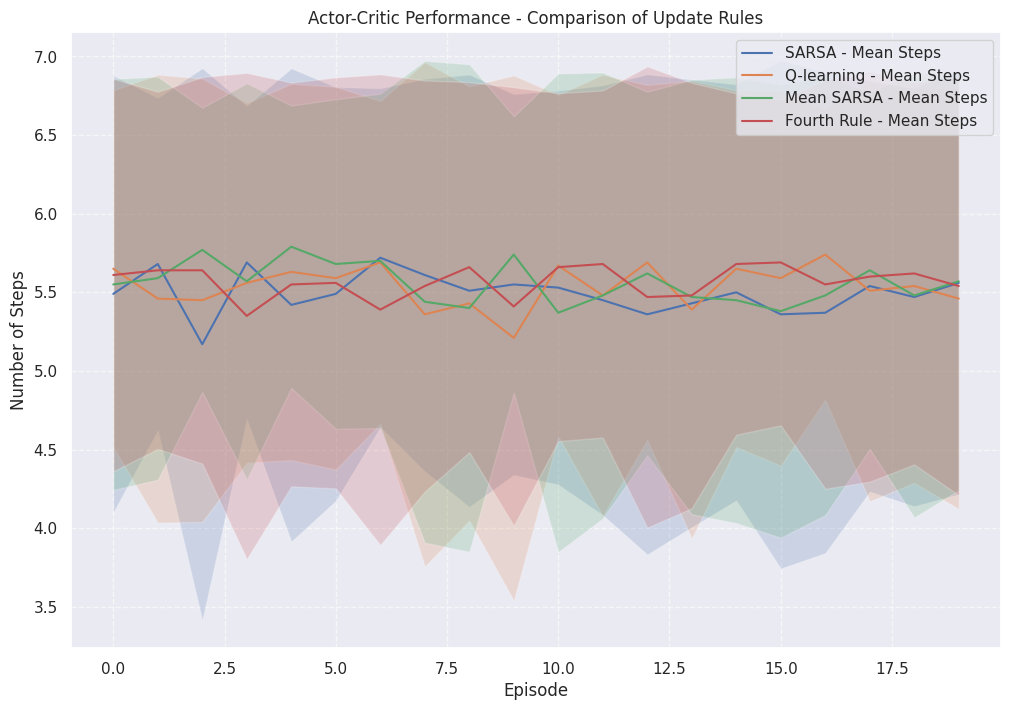

Streaming output truncated to the last 5000 lines.
Norm of Q-values: 0.0
delta (4) - State: 19, Action: 1, Delta: 1.0
Policy sum for state 19: 1.0
Norm of Q-values: 0.01
 Actor_critic_q function - looping Episode 15/20
Step: 0, State: 17, Terminated: False, Truncated: False
delta (4) - State: 17, Action: 1, Delta: 0.0
Policy sum for state 17: 1.0
Norm of Q-values: 0.01
delta (4) - State: 17, Action: 1, Delta: 0.0
Policy sum for state 17: 1.0
Norm of Q-values: 0.01
delta (4) - State: 17, Action: 2, Delta: 0.0
Policy sum for state 17: 1.0
Norm of Q-values: 0.01
delta (4) - State: 17, Action: 2, Delta: 0.0
Policy sum for state 17: 1.0
Norm of Q-values: 0.01
delta (4) - State: 17, Action: 3, Delta: 0.0
Policy sum for state 17: 1.0
Norm of Q-values: 0.01
delta (4) - State: 12, Action: 0, Delta: 0.0
Policy sum for state 12: 1.0
Stagnation detected after 6 steps. Avg reward: 0.0
 Actor_critic_q function - looping Episode 16/20
Step: 0, State: 2, Terminated: False, Truncated: False
delta (4) -

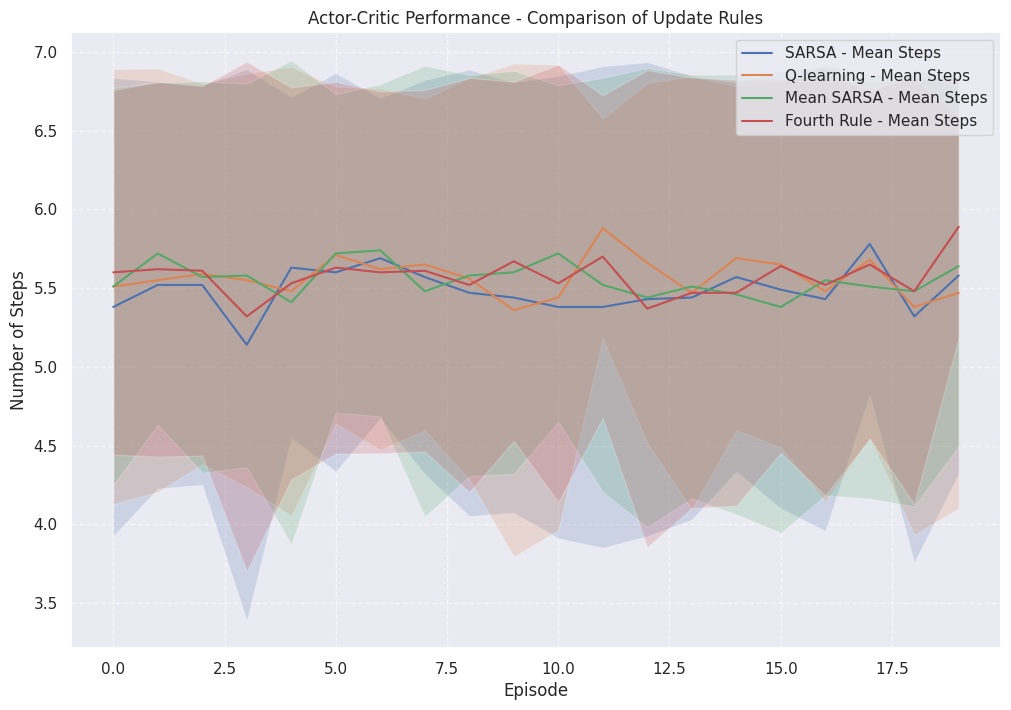

Streaming output truncated to the last 5000 lines.
Norm of Q-values: 0.014142422022275856
delta (4) - State: 9, Action: 3, Delta: 0.0
Policy sum for state 9: 1.0
Stagnation detected after 6 steps. Avg reward: 0.0
 Actor_critic_q function - looping Episode 18/20
Step: 0, State: 18, Terminated: False, Truncated: False
delta (4) - State: 18, Action: 2, Delta: 0.0
Policy sum for state 18: 1.0
Norm of Q-values: 0.014142422022275856
delta (4) - State: 18, Action: 3, Delta: 0.0
Policy sum for state 18: 1.0
Norm of Q-values: 0.014142422022275856
delta (4) - State: 13, Action: 1, Delta: 0.0
Policy sum for state 13: 1.0
Norm of Q-values: 0.014142422022275856
delta (4) - State: 13, Action: 1, Delta: 0.0
Policy sum for state 13: 1.0
Norm of Q-values: 0.014142422022275856
delta (4) - State: 13, Action: 0, Delta: 0.0
Policy sum for state 13: 1.0
Norm of Q-values: 0.014142422022275856
delta (4) - State: 12, Action: 1, Delta: 0.0
Policy sum for state 12: 1.0
Stagnation detected after 6 steps. Avg rewa

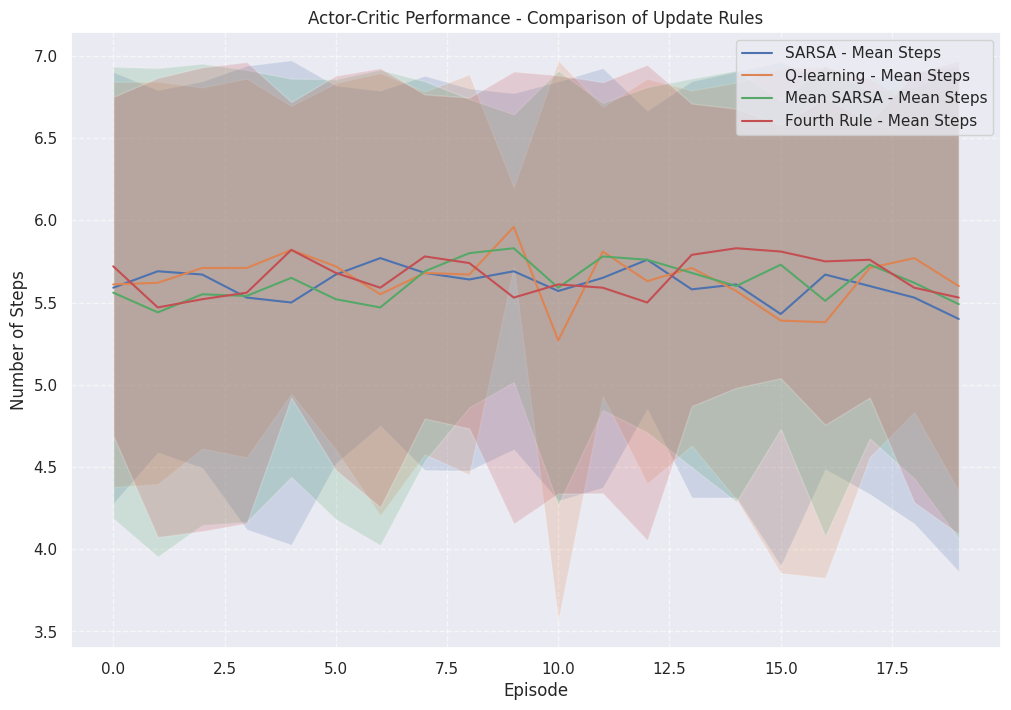

Temps d'exécution pour 100 runs avec gamma = 0.99 : 0:00:06.933779



In [ ]:
gammas = [0.9, 0.95, 0.99]  # Valeurs de gamma à tester

for gamma in gammas:
    print(f"Test avec gamma = {gamma}")

    ac_params = {
        "save_curves": False,
        "save_heatmap": True,
        "mdp": {
            "name": "MazeMDP-v0",
            "width": 5,
            "height": 5,
            "ratio": 0.2,
            "render_mode": "rgb_array",
            "gamma": gamma,  # Ajouter gamma ici
        },
        "log_dir": "./tmp",
        "video_dir": "./tmp/videos",
        "nb_episodes": 100,
        "render": False,
        "nb_repeats": 5,
        "alpha_critic": 0.8,
        "alpha_actor": 0.5,
    }

    cfg = OmegaConf.create(ac_params)
    mdp = make_mdp(cfg)  # Création de l'environnement avec la nouvelle valeur de gamma

    import time
    from datetime import timedelta
    N = 100

    start_time = time.time()  # mesurer temps
    plot_steps(nb_runs=N)
    end_time = time.time()

    elapsed_time = timedelta(seconds=(end_time - start_time))
    print(f"Temps d'exécution pour {N} runs avec gamma = {gamma} : {elapsed_time}\n")


# Agreement Between Actor and Critic

In [19]:
def compare_actor_critic_agreement(policy: np.ndarray, q: np.ndarray, show_table: bool = True, show_plot: bool = True) -> Tuple[float, List[int]]:
    """
    Compare actor's and critic's preferred actions for each state, and visualize the agreement.

    :param policy: the learned policy (shape: nb_states x nb_actions)
    :param q: the learned Q-table (shape: nb_states x nb_actions)
    :param show_table: whether to display a pandas table of the agreement
    :param show_plot: whether to display a heatmap of the agreement
    :return: (agreement %, list of agreeing states)
    """
    nb_states = policy.shape[0]
    actor_actions = np.argmax(policy, axis=1)
    critic_actions = np.argmax(q, axis=1)
    agreement = actor_actions == critic_actions

    df = pd.DataFrame({
        "State": range(nb_states),
        "Actor Action": actor_actions,
        "Critic Action": critic_actions,
        "Agreement": ["✅" if a else "❌" for a in agreement]
    })

    agree_states = df[df["Agreement"] == "✅"]["State"].tolist()
    agree_percent = len(agree_states) / nb_states * 100

    if show_table:
        print("\n Agreement Table:")
        display(df)

    if show_plot:
        # Creation d'une heatmap 1D : 1 = accord, 0 = desaccord
        plt.figure(figsize=(12, 1))
        sns.heatmap([agreement.astype(int)], cmap="Greens", cbar=False, xticklabels=range(nb_states))
        plt.title(f"Actor-Critic Agreement Heatmap ({agree_percent:.2f}%)", fontsize=14)
        plt.xlabel("States")
        plt.yticks([])
        plt.show()

    return agree_percent, agree_states


In [ ]:
value_norms, steps, policy, q = actor_critic_q(
    mdp,
    nb_episodes=30,
    alpha_critic=0.5,
    alpha_actor=0.5,
    update_type=1
)


 Agreement Table:


,State,Actor Action,Critic Action,Agreement
0,0,0,0,✅
1,1,0,0,✅
2,2,0,0,✅
3,3,0,0,✅
4,4,0,0,✅
5,5,0,0,✅
6,6,0,0,✅
7,7,0,0,✅
8,8,0,0,✅
9,9,0,0,✅


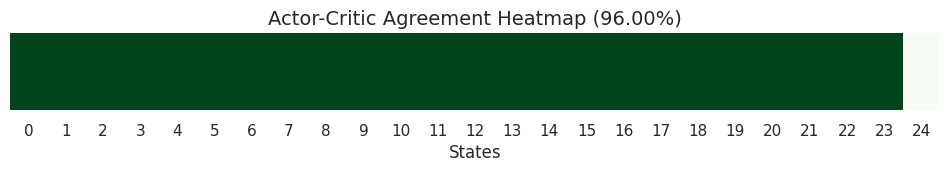

(96.0,
 [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23])

In [22]:
# Comparaison acteur/critique
compare_actor_critic_agreement(policy, q)